In [1]:
import joblib
import sys
sys.path.append('..')
from src.preprocess import load_and_preprocess
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

model  = joblib.load('../models/rf_model.pkl')
scaler = joblib.load('../models/scaler.pkl')

X, y = load_and_preprocess()
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y_pred = model.predict(X_test)
print("Model loaded and predictions done!")

Fetching KDD Cup 99 dataset...
Dataset shape: (494021, 15)
Label distribution:
attack_category
DoS       391458
Normal     97278
Probe       4107
R2L         1126
U2R           52
Name: count, dtype: int64
Model loaded and predictions done!


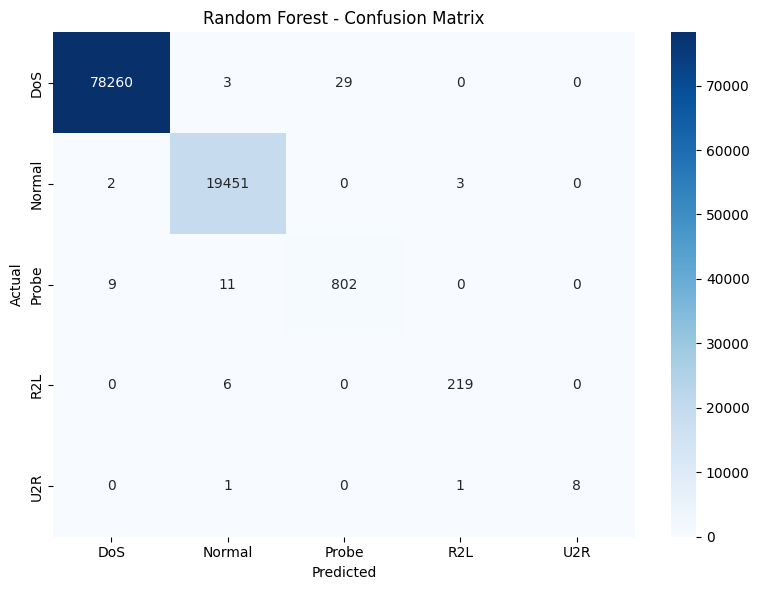

In [2]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png')
plt.show()

In [3]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=model.classes_))

              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00     78292
      Normal       1.00      1.00      1.00     19456
       Probe       0.97      0.98      0.97       822
         R2L       0.98      0.97      0.98       225
         U2R       1.00      0.80      0.89        10

    accuracy                           1.00     98805
   macro avg       0.99      0.95      0.97     98805
weighted avg       1.00      1.00      1.00     98805

